In [1]:
from pathlib import Path
import pandas as pd

from nyc_mobility_friction.paths import get_project_paths

import duckdb


paths = get_project_paths()
folder = paths.processed / "taxi" / "*.parquet"

con = duckdb.connect()

df = con.execute(f"""
    SELECT *
    FROM read_parquet('{folder.as_posix()}')
""").df()

print(df.shape)
print(df.head())

(172194, 9)
   pickup_zone_id pickup_date  trip_count  median_trip_duration_min  \
0             138  2023-12-31           1                 14.516667   
1             144  2023-12-31           1                  4.550000   
2             161  2023-12-31           1                 10.000000   
3             163  2023-12-31           1                  3.716667   
4             229  2023-12-31           1                 18.750000   

   p90_trip_duration_min  median_trip_distance  median_pace_min_per_mile  \
0              14.516667                  8.39                  1.730234   
1               4.550000                  0.53                  8.584906   
2              10.000000                  0.59                 16.949153   
3               3.716667                  0.97                  3.831615   
4              18.750000                  7.70                  2.435065   

   p90_pace_min_per_mile  total_fare_amount  
0               1.730234               33.1  
1           

In [2]:
import pandas as pd
import numpy as np

taxi = df.copy()

taxi["pickup_date"] = pd.to_datetime(taxi["pickup_date"], errors="coerce")
taxi["pickup_zone_id"] = taxi["pickup_zone_id"].astype("Int64")

taxi = taxi.dropna(subset=["pickup_date", "pickup_zone_id", "trip_count"]).copy()

# If duplicates are exact duplicates:
taxi = taxi.drop_duplicates(subset=["pickup_date", "pickup_zone_id"]).copy()

# Time features
taxi["year"] = taxi["pickup_date"].dt.year
taxi["month"] = taxi["pickup_date"].dt.month
taxi["month_name"] = taxi["pickup_date"].dt.month_name()
taxi["day_of_week"] = taxi["pickup_date"].dt.dayofweek
taxi["day_name"] = taxi["pickup_date"].dt.day_name()
taxi["year_month"] = taxi["pickup_date"].dt.to_period("M").astype(str)

print(taxi.shape)
print(taxi["pickup_date"].min(), taxi["pickup_date"].max())
print("zones:", taxi["pickup_zone_id"].nunique())

(171966, 15)
2023-12-31 00:00:00 2025-12-31 00:00:00
zones: 263


In [3]:
taxi = (
    taxi.groupby(["pickup_date", "pickup_zone_id"], as_index=False)
    .agg(
        trip_count=("trip_count", "sum"),
        total_fare_amount=("total_fare_amount", "sum"),
        median_trip_duration_min=("median_trip_duration_min", "mean"),
        p90_trip_duration_min=("p90_trip_duration_min", "mean"),
        median_trip_distance=("median_trip_distance", "mean"),
        median_pace_min_per_mile=("median_pace_min_per_mile", "mean"),
        p90_pace_min_per_mile=("p90_pace_min_per_mile", "mean"),
    )
)

taxi["year"] = taxi["pickup_date"].dt.year
taxi["month"] = taxi["pickup_date"].dt.month
taxi["month_name"] = taxi["pickup_date"].dt.month_name()
taxi["day_of_week"] = taxi["pickup_date"].dt.dayofweek
taxi["day_name"] = taxi["pickup_date"].dt.day_name()
taxi["year_month"] = taxi["pickup_date"].dt.to_period("M").astype(str)

In [4]:
import plotly.express as px
import plotly.graph_objects as go

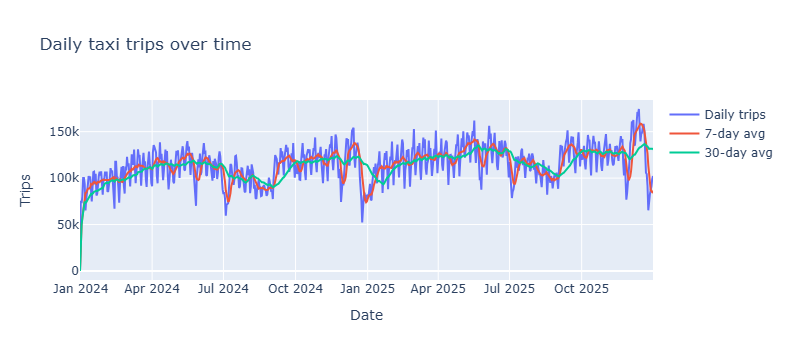

In [5]:
daily = (
    taxi.groupby("pickup_date", as_index=False)
    .agg(
        total_trips=("trip_count", "sum"),
        total_fare=("total_fare_amount", "sum"),
        avg_median_pace=("median_pace_min_per_mile", "mean"),
        avg_median_duration=("median_trip_duration_min", "mean"),
    )
    .sort_values("pickup_date")
)

daily["trips_7d_avg"] = daily["total_trips"].rolling(7, min_periods=1).mean()
daily["trips_30d_avg"] = daily["total_trips"].rolling(30, min_periods=1).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily["pickup_date"], y=daily["total_trips"], mode="lines", name="Daily trips"))
fig.add_trace(go.Scatter(x=daily["pickup_date"], y=daily["trips_7d_avg"], mode="lines", name="7-day avg"))
fig.add_trace(go.Scatter(x=daily["pickup_date"], y=daily["trips_30d_avg"], mode="lines", name="30-day avg"))

fig.update_layout(
    title="Daily taxi trips over time",
    xaxis_title="Date",
    yaxis_title="Trips",
    hovermode="x unified"
)

fig.show()

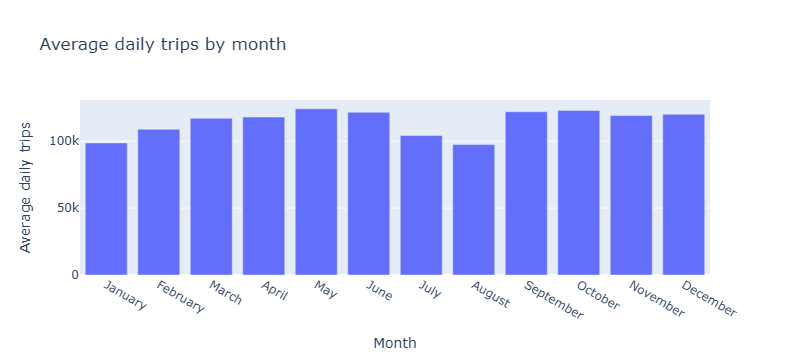

In [6]:
month_daily = (
    taxi.groupby(["pickup_date", "year", "month", "month_name"], as_index=False)
    .agg(total_trips=("trip_count", "sum"))
)

month_seasonality = (
    month_daily.groupby(["month", "month_name"], as_index=False)
    .agg(avg_daily_trips=("total_trips", "mean"))
    .sort_values("month")
)

fig = px.bar(
    month_seasonality,
    x="month_name",
    y="avg_daily_trips",
    title="Average daily trips by month",
    labels={"month_name": "Month", "avg_daily_trips": "Average daily trips"}
)

fig.show()

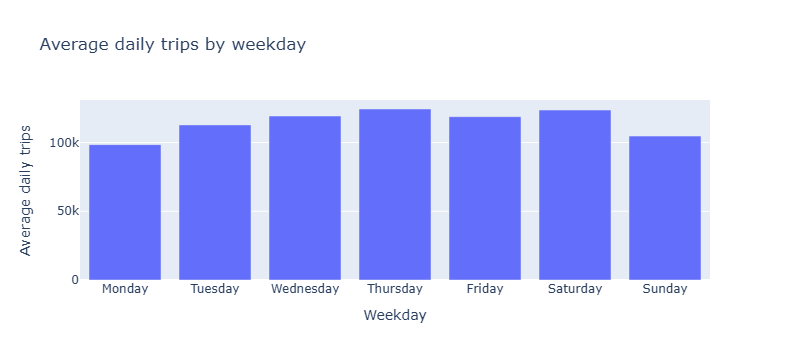

In [7]:
weekday = (
    taxi.groupby(["pickup_date", "day_of_week", "day_name"], as_index=False)
    .agg(total_trips=("trip_count", "sum"))
    .groupby(["day_of_week", "day_name"], as_index=False)
    .agg(avg_daily_trips=("total_trips", "mean"))
    .sort_values("day_of_week")
)

fig = px.bar(
    weekday,
    x="day_name",
    y="avg_daily_trips",
    title="Average daily trips by weekday",
    labels={"day_name": "Weekday", "avg_daily_trips": "Average daily trips"}
)

fig.show()

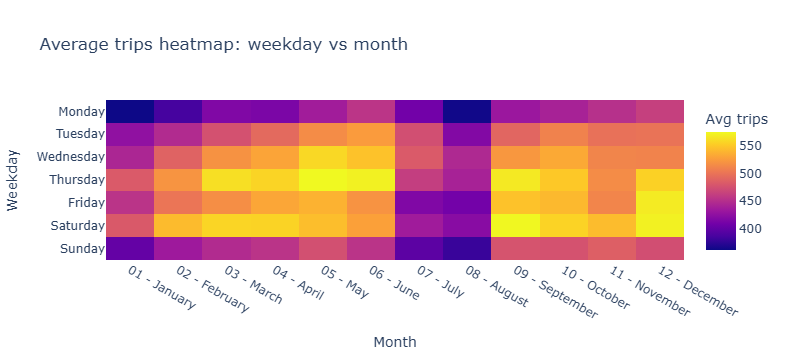

In [8]:
heat = (
    taxi.groupby(["month", "month_name", "day_of_week", "day_name"], as_index=False)
    .agg(avg_trips=("trip_count", "mean"))
)

heat["month_label"] = heat["month"].astype(str).str.zfill(2) + " - " + heat["month_name"]

pivot_heat = heat.pivot(index="day_name", columns="month_label", values="avg_trips")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_heat = pivot_heat.reindex(weekday_order)

fig = px.imshow(
    pivot_heat,
    aspect="auto",
    title="Average trips heatmap: weekday vs month",
    labels=dict(x="Month", y="Weekday", color="Avg trips")
)

fig.show()

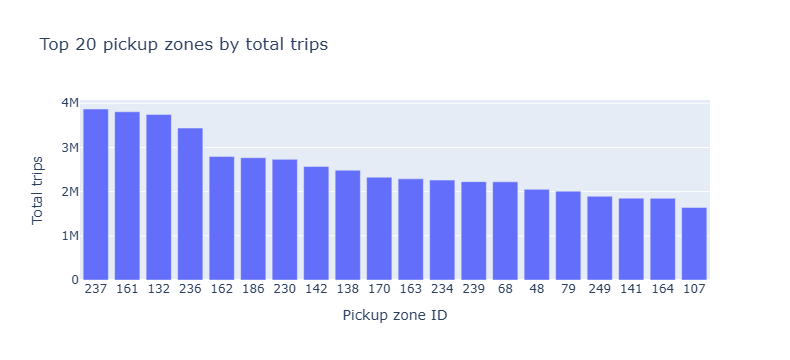

In [9]:
top_zones = (
    taxi.groupby("pickup_zone_id", as_index=False)
    .agg(
        total_trips=("trip_count", "sum"),
        avg_daily_trips=("trip_count", "mean"),
        total_fare=("total_fare_amount", "sum"),
        avg_median_duration=("median_trip_duration_min", "mean"),
        avg_median_distance=("median_trip_distance", "mean"),
        avg_median_pace=("median_pace_min_per_mile", "mean"),
    )
    .sort_values("total_trips", ascending=False)
)

top20 = top_zones.head(20).copy()
top20["pickup_zone_id"] = top20["pickup_zone_id"].astype(str)

fig = px.bar(
    top20,
    x="pickup_zone_id",
    y="total_trips",
    hover_data=["avg_daily_trips", "total_fare", "avg_median_duration", "avg_median_distance", "avg_median_pace"],
    title="Top 20 pickup zones by total trips",
    labels={"pickup_zone_id": "Pickup zone ID", "total_trips": "Total trips"}
)

fig.show()

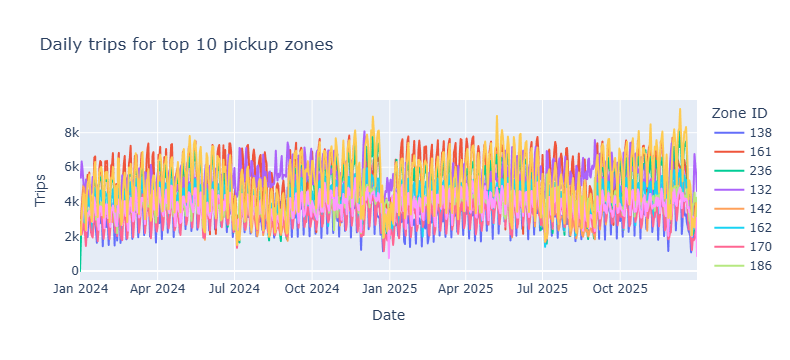

In [10]:
top10_ids = top_zones.head(10)["pickup_zone_id"].tolist()

top10_daily = (
    taxi[taxi["pickup_zone_id"].isin(top10_ids)]
    .groupby(["pickup_date", "pickup_zone_id"], as_index=False)
    .agg(total_trips=("trip_count", "sum"))
)

top10_daily["pickup_zone_id"] = top10_daily["pickup_zone_id"].astype(str)

fig = px.line(
    top10_daily,
    x="pickup_date",
    y="total_trips",
    color="pickup_zone_id",
    title="Daily trips for top 10 pickup zones",
    labels={"pickup_date": "Date", "total_trips": "Trips", "pickup_zone_id": "Zone ID"}
)

fig.update_layout(hovermode="x unified")
fig.show()

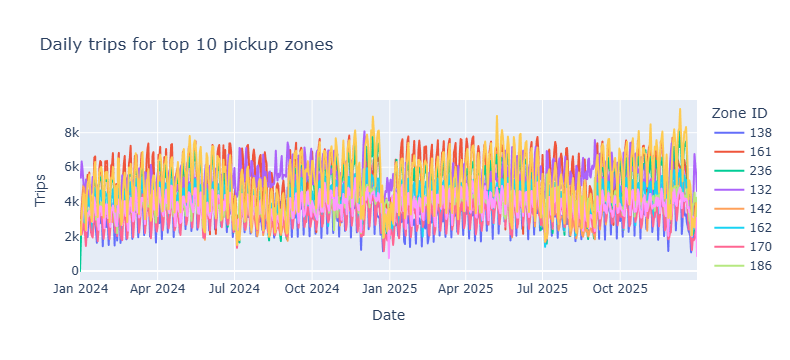

In [11]:
top10_ids = top_zones.head(10)["pickup_zone_id"].tolist()

top10_daily = (
    taxi[taxi["pickup_zone_id"].isin(top10_ids)]
    .groupby(["pickup_date", "pickup_zone_id"], as_index=False)
    .agg(total_trips=("trip_count", "sum"))
)

top10_daily["pickup_zone_id"] = top10_daily["pickup_zone_id"].astype(str)

fig = px.line(
    top10_daily,
    x="pickup_date",
    y="total_trips",
    color="pickup_zone_id",
    title="Daily trips for top 10 pickup zones",
    labels={"pickup_date": "Date", "total_trips": "Trips", "pickup_zone_id": "Zone ID"}
)

fig.update_layout(hovermode="x unified")
fig.show()

In [17]:
taxi.columns

Index(['pickup_date', 'pickup_zone_id', 'trip_count', 'total_fare_amount',
       'median_trip_duration_min', 'p90_trip_duration_min',
       'median_trip_distance', 'median_pace_min_per_mile',
       'p90_pace_min_per_mile', 'year', 'month', 'month_name', 'day_of_week',
       'day_name', 'year_month'],
      dtype='str')

In [18]:
import pandas as pd
import numpy as np
import plotly.express as px

plot_df = taxi.copy()

plot_df["pickup_date"] = pd.to_datetime(plot_df["pickup_date"], errors="coerce")
plot_df["trip_count"] = pd.to_numeric(plot_df["trip_count"], errors="coerce")
plot_df["median_pace_min_per_mile"] = pd.to_numeric(plot_df["median_pace_min_per_mile"], errors="coerce")
plot_df["median_trip_duration_min"] = pd.to_numeric(plot_df["median_trip_duration_min"], errors="coerce")
plot_df["median_trip_distance"] = pd.to_numeric(plot_df["median_trip_distance"], errors="coerce")
plot_df["total_fare_amount"] = pd.to_numeric(plot_df["total_fare_amount"], errors="coerce")

plot_df = plot_df.dropna(subset=["pickup_date", "trip_count"]).copy()

def weighted_avg(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0 or weights[mask].sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

daily_avg = (
    plot_df.groupby("pickup_date")
    .apply(lambda g: pd.Series({
        "trip_count": g["trip_count"].sum(),
        "total_fare_amount": g["total_fare_amount"].sum(),
        "avg_median_pace_min_per_mile": weighted_avg(g["median_pace_min_per_mile"], g["trip_count"]),
        "avg_median_trip_duration_min": weighted_avg(g["median_trip_duration_min"], g["trip_count"]),
        "avg_median_trip_distance": weighted_avg(g["median_trip_distance"], g["trip_count"]),
        "n_zones": g["pickup_zone_id"].nunique()
    }))
    .reset_index()
)

daily_avg["month_name"] = daily_avg["pickup_date"].dt.month_name()
daily_avg["pickup_date_str"] = daily_avg["pickup_date"].dt.strftime("%Y-%m-%d")

print(daily_avg.head())

  pickup_date  trip_count  total_fare_amount  avg_median_pace_min_per_mile  \
0  2023-12-31         7.0             121.10                      6.408111   
1  2024-01-01     75527.0         1676372.78                      4.855734   
2  2024-01-02     73004.0         1561127.11                      5.568436   
3  2024-01-03     79954.0         1604789.52                      5.846854   
4  2024-01-04    100146.0         1879316.94                      6.194442   

   avg_median_trip_duration_min  avg_median_trip_distance  n_zones month_name  \
0                     11.742857                  3.385714      7.0   December   
1                     12.996015                  3.490567    230.0    January   
2                     13.961586                  3.533161    220.0    January   
3                     13.770214                  3.227536    226.0    January   
4                     13.437934                  2.822800    220.0    January   

  pickup_date_str  
0      2023-12-31  
1   